# Sales Data Analysis Project

## Dataset Exploration
This section loads the dataset and performs initial exploration to understand the structure of the data.

In [1]:
import pandas as pd

# load dataset
data = pd.read_csv("train.csv")

# show first rows
data.head()



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [12]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

## Sales by Category 
This section loads the dataset and performs initial exploration to understand the structure of the data.

In [13]:
sales_by_category = data.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


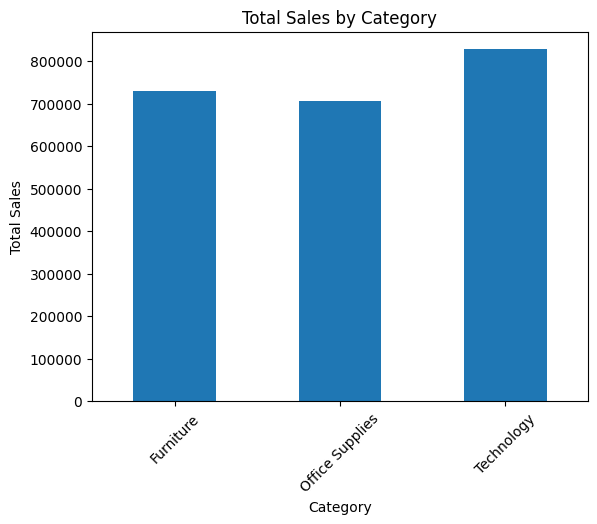

In [14]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind='bar')
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## Sales by Region
This section analyzes regional sales performance to determine which geographic region contributes the most revenue.

In [15]:
sales_by_region = data.groupby("Region")["Sales"].sum()

sales_by_region

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64

## Monthly Sales Trend Analysis
This analysis examines how sales change over time to identify seasonal trends and patterns.

In [3]:
#convert to datatime
data["Order Date"] = pd.to_datetime(data["Order Date"])
#extract month data
data["Month"] = data["Order Date"].dt.to_period("M")
#group by month 
monthly_sales = data.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
2015-01    28828.2540
2015-02    12588.4840
2015-03    54027.6920
2015-04    24710.0160
2015-05    29520.4900
2015-06    29181.3346
2015-07    35194.5580
2015-08    37349.2655
2015-09    65956.3998
2015-10    34561.9470
2015-11    64369.4565
2015-12    63568.3107
2016-01    29347.3864
2016-02    20728.3520
2016-03    34489.6776
2016-04    38056.9685
2016-05    30761.5585
2016-06    28515.9082
2016-07    28573.3100
2016-08    49076.9300
2016-09    65352.9970
2016-10    31631.8890
2016-11    50009.1450
2016-12    52891.8832
2017-01    38048.1840
2017-02    48907.5900
2017-03    48990.1410
2017-04    42368.0480
2017-05    64836.2518
2017-06    37424.6810
2017-07    41761.9430
2017-08    45766.8144
2017-09    40692.3063
2017-10    52156.9580
2017-11    66392.5470
2017-12    72847.0855
2018-01    59767.0910
2018-02    48928.8334
2018-03    74748.6238
2018-04    37849.2156
2018-05    40882.4464
2018-06    46912.8475
2018-07    53942.7755
2018-08    75408.7840
2018-09    73153.3640
2018

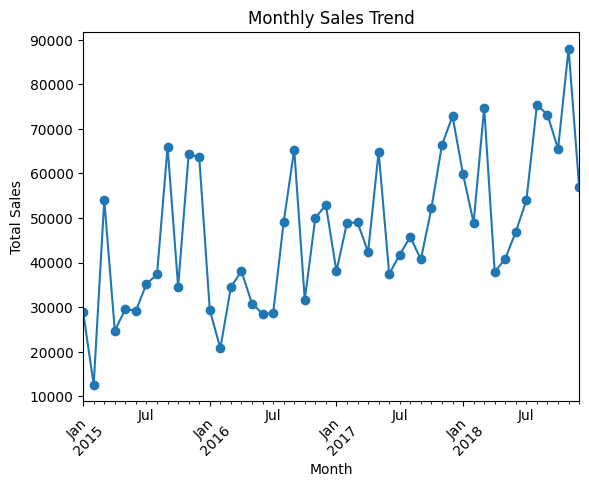

In [4]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## Sales by Customer Segment
This analysis evaluates which customer segment generates the most sales.

In [23]:
sales_by_segment = data.groupby("Segment")["Sales"].sum()

sales_by_segment

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

## Sales by Sub-Category
This section examines individual product sub-categories to identify top-performing and low-performing products.

In [24]:
sales_by_subcategory = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
sales_by_subcategory

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64